<a href="https://colab.research.google.com/github/anaraquelslv/inteligencia-artificial-umc/blob/main/Atividade_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("menegidio/fishmorph-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fishmorph-dataset' dataset.
Path to dataset files: /kaggle/input/fishmorph-dataset


Passo 1: carregar o dataset

In [6]:
import os, glob
import pandas as pd

print(os.listdir(path))

arquivos = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print(arquivos)

df = pd.read_csv(arquivos[1])  # se houver mais de um CSV, escolha o certo
df.head()

['FISHMORPH_Order_Dataset.csv', 'FISHMORPH_Family_Dataset.csv']
['/kaggle/input/fishmorph-dataset/FISHMORPH_Order_Dataset.csv', '/kaggle/input/fishmorph-dataset/FISHMORPH_Family_Dataset.csv']


,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Family
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cyprinidae
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Cichlidae
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cyprinidae
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cyprinidae
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cyprinidae


Passo 2: análise padrão e limpeza

In [7]:
print("Shape:", df.shape)
df.info()

Shape: (8342, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8342 entries, 0 to 8341
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MBl     8342 non-null   float64
 1   BEl     8342 non-null   float64
 2   VEp     8342 non-null   float64
 3   REs     8342 non-null   float64
 4   OGp     8342 non-null   float64
 5   RMl     8342 non-null   float64
 6   BLs     8342 non-null   float64
 7   PFv     8342 non-null   float64
 8   PFs     8342 non-null   float64
 9   CPt     8342 non-null   float64
 10  Family  8342 non-null   object 
dtypes: float64(10), object(1)
memory usage: 717.0+ KB


In [8]:
print("Nulos por coluna:")
print(df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())
df.describe()

Nulos por coluna:
MBl       0
BEl       0
VEp       0
REs       0
OGp       0
RMl       0
BLs       0
PFv       0
PFs       0
CPt       0
Family    0
dtype: int64

Duplicados: 1


,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt
count,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000
mean,22.004517,4.452438,0.549087,0.391665,0.381768,0.399786,0.571818,0.285316,0.189343,2.560795
std,33.612007,2.338235,0.094883,0.132814,0.194352,0.302658,0.117486,0.155629,0.056109,1.016659
min,1.200000,1.033084,0.159248,0.000000,0.000000,0.000000,0.224525,0.000000,0.000000,0.000000
25%,7.000000,3.139102,0.487993,0.293205,0.278014,0.257999,0.490052,0.193134,0.157972,1.999744
50%,12.600000,4.038851,0.546213,0.389429,0.406904,0.361436,0.564739,0.275039,0.183497,2.436329
75%,24.500000,5.002621,0.605125,0.486221,0.516001,0.490671,0.648039,0.368876,0.215031,2.919818
max,800.000000,43.728161,1.000000,1.026667,1.026316,7.060344,1.230105,0.857097,0.511113,15.452061


In [9]:
# Limpeza: remove duplicados e linhas com nulos
df = df.drop_duplicates()
df = df.dropna().reset_index(drop=True)
print("Shape após limpeza:", df.shape)

Shape após limpeza: (8341, 11)


Passo 3: distribuição das categorias

['Family']
Family
Cyprinidae         1545
Cichlidae          1060
Characidae          732
Loricariidae        427
Percidae            190
                   ... 
Sillaginidae          1
Serrasalmidae         1
Bythitidae            1
Vaillantellidae       1
Valenciidae           1
Name: count, Length: 197, dtype: int64
Nº de classes: 197


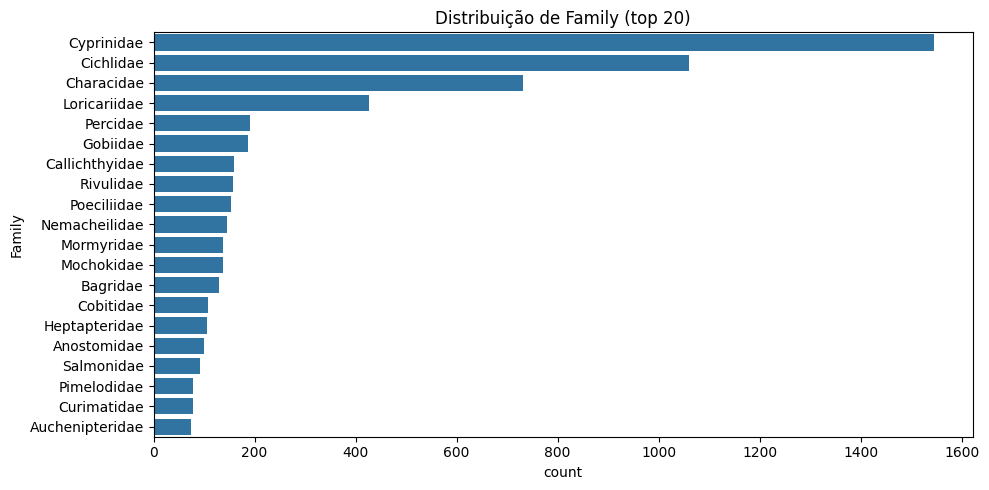

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df.select_dtypes(include="object").columns.tolist())

ALVO = "Family"  # <-- ajuste para a coluna de classe que você quer prever

contagem = df[ALVO].value_counts()
print(contagem)
print("Nº de classes:", contagem.shape[0])

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y=ALVO, order=contagem.index[:20])
plt.title(f"Distribuição de {ALVO} (top 20)")
plt.tight_layout()
plt.show()

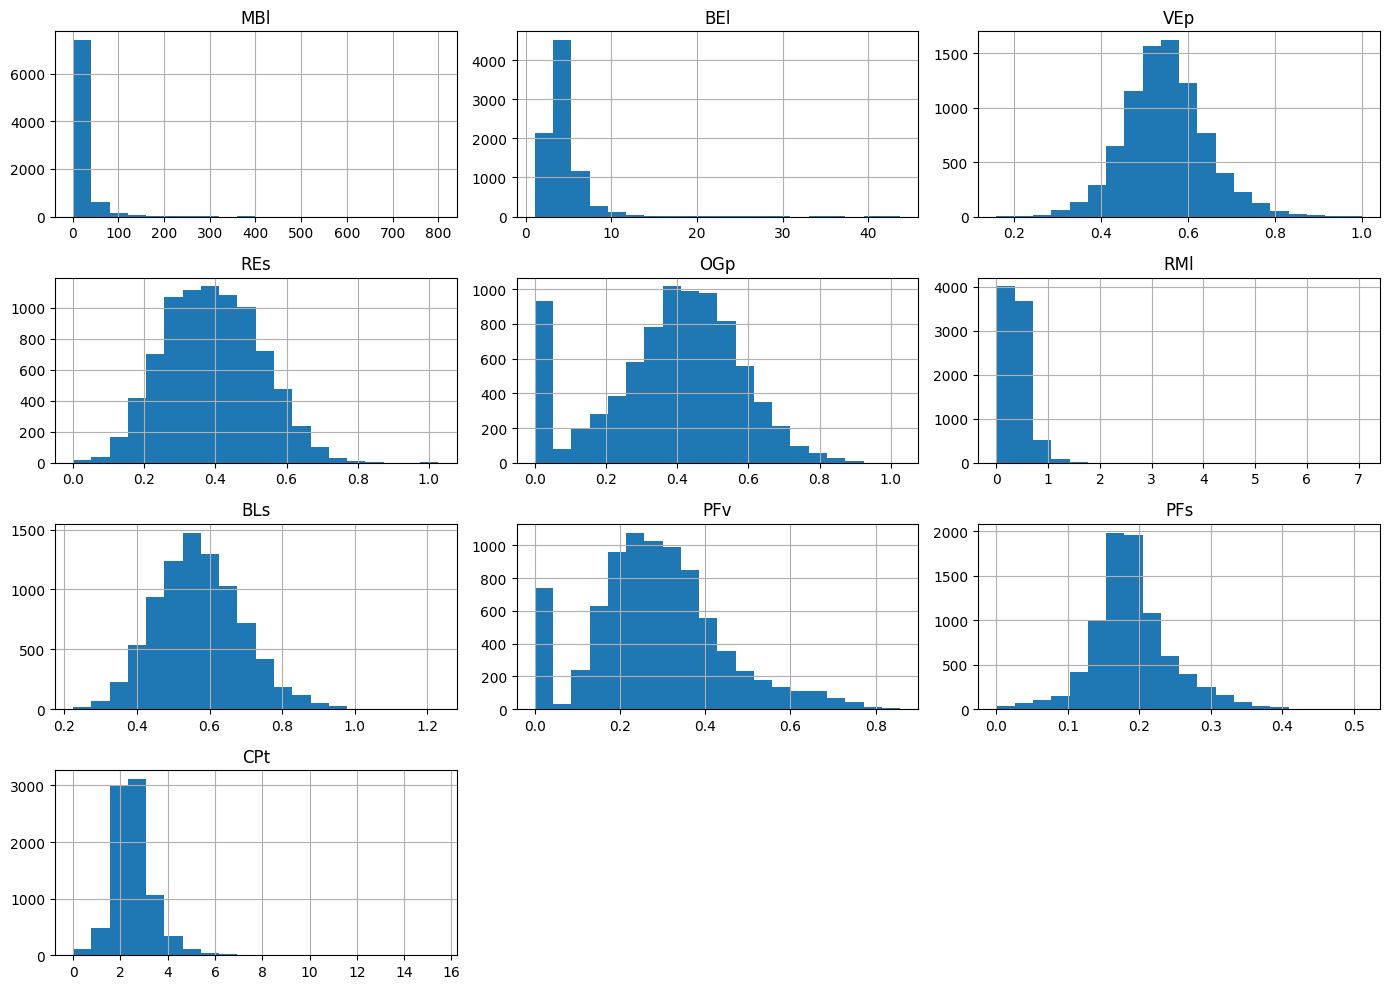

In [12]:
# Distribuição das variáveis numéricas
df.select_dtypes(include="number").hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

Passo 4: divisão treino/teste e validação cruzada

In [15]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# mantém só classes com pelo menos 5 exemplos (precisa ser >= nº de folds)
MIN_EXEMPLOS = 5
validas = df[ALVO].value_counts()
validas = validas[validas >= MIN_EXEMPLOS].index
dados = df[df[ALVO].isin(validas)]
print("Classes mantidas:", len(validas), "| Linhas:", len(dados))

# X = só colunas numéricas; y = classe
X = dados.select_dtypes(include="number")
y = dados[ALVO]
print("Features usadas:", X.columns.tolist())

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_treino.shape, X_teste.shape)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

Classes mantidas: 118 | Linhas: 8188
Features usadas: ['MBl', 'BEl', 'VEp', 'REs', 'OGp', 'RMl', 'BLs', 'PFv', 'PFs', 'CPt']
(6550, 10) (1638, 10)


Passo 5: Grid Search (SVM com 4 valores por hiperparâmetro)

In [17]:
from sklearn.model_selection import GridSearchCV, train_test_split

# 1) Amostra estratificada de 30% do treino, só para a busca
X_busca, _, y_busca, _ = train_test_split(
    X_treino, y_treino, train_size=0.3, stratify=y_treino, random_state=42
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(cache_size=1000))
])

param_grid = {
    "svc__kernel": ["linear", "poly", "rbf", "sigmoid"],
    "svc__C":      [0.1, 1, 10, 100],
    "svc__gamma":  [0.001, 0.01, 0.1, 1],
}

grid = GridSearchCV(
    pipe, param_grid, cv=cv, scoring="accuracy",
    n_jobs=-1, verbose=3
)
grid.fit(X_busca, y_busca)

# 2) Reajusta o melhor modelo com TODOS os dados de treino
melhor = grid.best_estimator_
melhor.fit(X_treino, y_treino)

Fitting 3 folds for each of 64 candidates, totalling 192 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', SVC(C=100, cache_size=1000, gamma=0.01))])

Passo 6: melhor modelo, parâmetros e acurácia

In [18]:
from sklearn.metrics import accuracy_score

print("Modelo:", melhor.named_steps["svc"])
print("Melhores parâmetros:", grid.best_params_)
print(f"Acurácia média (validação cruzada, amostra de 30%): {grid.best_score_:.4f}")

y_pred = melhor.predict(X_teste)
print(f"Acurácia no conjunto de teste: {accuracy_score(y_teste, y_pred):.4f}")

Modelo: SVC(C=100, cache_size=1000, gamma=0.01)
Melhores parâmetros: {'svc__C': 100, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Acurácia média (validação cruzada, amostra de 30%): 0.6173
Acurácia no conjunto de teste: 0.6496


In [19]:

res = pd.DataFrame(grid.cv_results_)
res[["param_svc__kernel", "param_svc__C", "param_svc__gamma",
     "mean_test_score", "std_test_score", "rank_test_score"]] \
    .sort_values("rank_test_score").head(10)

,param_svc__kernel,param_svc__C,param_svc__gamma,mean_test_score,std_test_score,rank_test_score
54,rbf,100.0,0.010,0.617303,0.005038,1
24,linear,1.0,0.100,0.605089,0.005621,2
20,linear,1.0,0.010,0.605089,0.005621,2
28,linear,1.0,1.000,0.605089,0.005621,2
16,linear,1.0,0.001,0.605089,0.005621,2
42,rbf,10.0,0.100,0.603053,0.011219,6
32,linear,10.0,0.001,0.590840,0.005434,7
40,linear,10.0,0.100,0.590840,0.005434,7
36,linear,10.0,0.010,0.590840,0.005434,7
44,linear,10.0,1.000,0.590840,0.005434,7


Passo 7: matriz de confusão

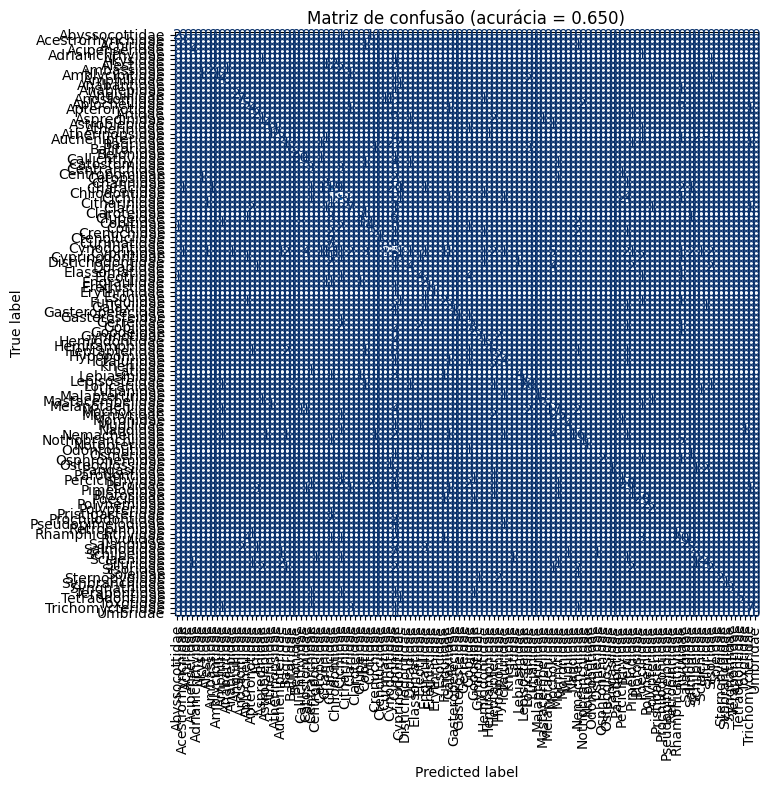

                   precision    recall  f1-score   support

   Abyssocottidae       0.50      0.50      0.50         4
Acestrorhynchidae       0.60      1.00      0.75         3
        Achiridae       0.00      0.00      0.00         2
    Acipenseridae       0.80      1.00      0.89         4
 Adrianichthyidae       0.00      0.00      0.00         1
         Akysidae       0.00      0.00      0.00         3
        Alestidae       0.00      0.00      0.00        15
       Ambassidae       0.67      0.40      0.50         5
   Amblycipitidae       1.00      0.33      0.50         3
      Amphiliidae       0.44      0.50      0.47         8
      Anabantidae       0.75      0.75      0.75         4
      Anablepidae       0.00      0.00      0.00         2
      Anguillidae       1.00      1.00      1.00         2
      Anostomidae       0.78      0.35      0.48        20
    Aplocheilidae       0.42      0.38      0.40        13
    Apteronotidae       0.44      0.57      0.50       

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

classes = melhor.classes_
cm = confusion_matrix(y_teste, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(
    ax=ax, xticks_rotation=90, cmap="Blues", colorbar=False
)
plt.title(f"Matriz de confusão (acurácia = {accuracy_score(y_teste, y_pred):.3f})")
plt.tight_layout()
plt.show()

print(classification_report(y_teste, y_pred, zero_division=0))